# Notebook F of more line ratios from saved maps from the PZ cubes

This is adapted from 01-02-yet-more-line-ratios. It includes the He II analysis


In [1]:
from pathlib import Path
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from mpdaf.obj import Image
from zz_utils import get_image_raw, ROOT
import regions
import sys
import pandas as pd
import cmasher as cmr
import pyneb as pn

sns.set_context("talk")
sns.set_color_codes()

/Users/will/Dropbox/muse-hii-regions/.venv/lib/python3.14/site-packages/mpdaf/version.py:34: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


## He II emission measure

In [2]:
he2 = pn.RecAtom("He", 2)
he1 = pn.RecAtom("He", 1)
h1 = pn.RecAtom("H", 1)

In [3]:
temperatures = [12500, 13800, 15500]
e4686 = he2.getEmissivity(tem=temperatures, den=1, wave=4686)
e4861 = h1.getEmissivity(tem=temperatures, den=1, wave=4861)
e5875 = he1.getEmissivity(tem=temperatures, den=1, wave=5876)
e4686, e4861, e5875

(array([1.20300000e-24, 1.08441739e-24, 9.59135484e-25]),
 array([1.01400000e-25, 9.26956522e-26, 8.33922581e-26]),
 array([1.31541290e-25, 1.17715862e-25, 1.03205588e-25]))

In [4]:
np.mean(e4861[1])

9.269565217391303e-26

From the other notebook, we measure 5875 / 4861 = 0.108 +/- 0.001

Whereas the ratio of emissivities is

In [5]:
e5875 / e4861

array([1.29725138, 1.26991784, 1.23759196])

This implies a He abundance of

In [6]:
np.array([0.107, 0.108, 0.109])[None, :] / (e5875 / e4861)[:, None]

array([[0.08248209, 0.08325295, 0.08402381],
       [0.08425742, 0.08504487, 0.08583232],
       [0.08645822, 0.08726624, 0.08807426]])

From Table 5 of Valerdi+ (2019), they have a He+ abundance of 10.915 or 10.917, with error of +/- 0.004 , so:

In [7]:
10 ** (np.array([10.915, 10.917]) - 12.0)

array([0.08222426, 0.08260379])

They find a small He++ abundance of

In [8]:
f"He++/H+ = {10 ** (8.30 - 12.0):.3e}; He++/He+ = {10 ** (8.30 - 10.915):.3e}"

'He++/H+ = 1.995e-04; He++/He+ = 2.427e-03'

In the bow shock I measure 4686 / 4861 = 0.015 or so, which would be 1.5 on a scale of Hβ = 100.  Mabel's Table 2 gives 0.24, which is 6 times less. This is consistent with the general value we find away from the bow's inner edge.

So, I can work out my own He++/H+ abundance:

In [9]:
y_heiii_hii = 0.015 / (e4686 / e4861)
y_heiii_heii = y_heiii_hii / 0.08167471
f"Bow shock He++/H+ = {np.round(y_heiii_hii, 4)}; He++/He+ = {np.round(y_heiii_heii, 4)}"

'Bow shock He++/H+ = [0.0013 0.0013 0.0013]; He++/He+ = [0.0155 0.0157 0.016 ]'

In other words, the He++ emission measure, $\int n(\mathrm{He^{++}})\, n_\mathrm{e}\, dz$, is ony 2.5% of the total $\int n(\mathrm{He^{+}})\, n_\mathrm{e}\, dz$.

*This is totally consistent, with the observed small change in 5875/4861, which is also about 2%*

**TODO**

- [ ] By assuming a path length, we can derive a density
- [ ] We can do the same with [Ar IV] and [Ar III]
- [ ] Ask Mabel to look at her slit A to see if she sees the He II and [Ar IV] signatures of the bow shock.  Also, maybe measure [O III] temperature to see if it goes up

### Conversion to a density

We want the surface brightness of He++ in physical units.

MUSE flux units are $10^{-20}\ \mathrm{erg\ s^{-1}\ cm^{-2}\ Å^{-1}\ pix^{-1}}$ in the cube, but we have summed over wavelength pixels, which are 1.4 Å.  The spatial pixels are 0.2 arcsec.

In [10]:
import astropy.units as u

In [11]:
muse_bright_unit = 1e-20 * 1.4 * u.erg / u.s / u.cm**2 / (0.2 * u.arcsec) ** 2
muse_bright_unit.to(u.erg / u.s / u.cm**2 / u.sr)

<Quantity 1.48908096e-08 erg / (s sr cm2)>

In [12]:
datadir = ROOT / "data"
figdir = ROOT / "figs"

In [13]:
im4686 = Image(str(datadir / "ngc346-ZZ-heii-4686-correct.fits"))
im5875 = Image(str(datadir / "ngc346-ZZ-hei-5875-correct.fits"))
imhb = Image(str(datadir / "ngc346-ZZ-hi-4861-correct.fits"))
imariv = Image(str(datadir / "ngc346-ZZ-ariv-4711-plus-4740-correct.fits"))
imariii = Image(str(datadir / "ngc346-ZZ-ariii-7136-correct.fits"))
imoiii = Image(str(datadir / "ngc346-ZZ-oiii-5007-correct.fits"))

Use the same bow shock window as in the E notebook

In [15]:
xslice, yslice = slice(230, 300), slice(144, 245)

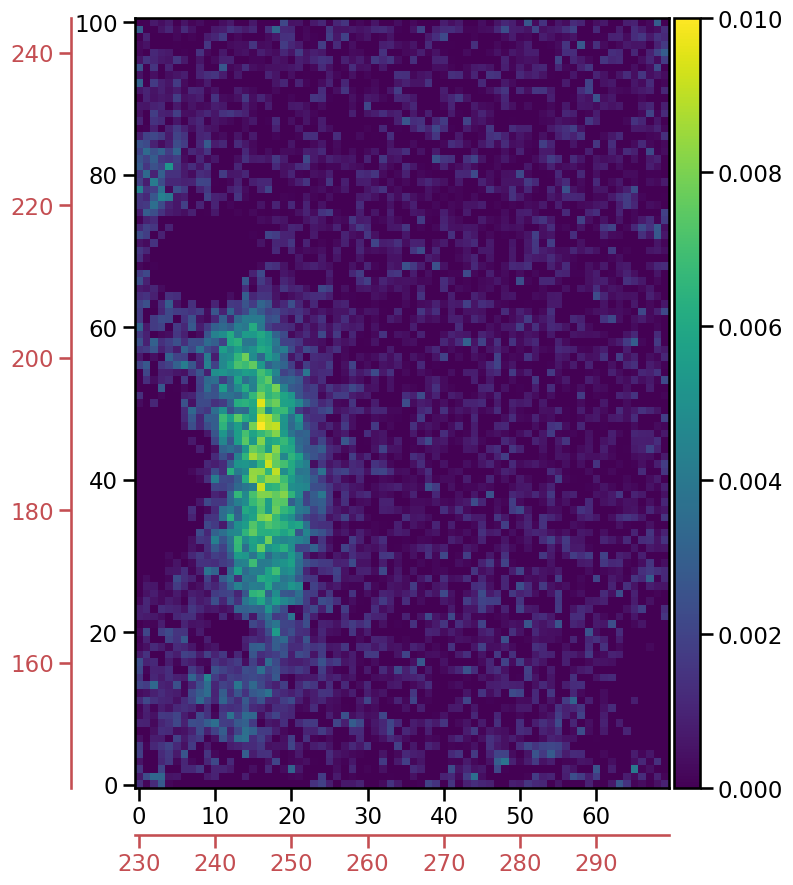

In [47]:
fig, ax = plt.subplots(figsize=(10, 10))
(im4686 / imhb)[yslice, xslice].plot(vmin=0.0, vmax=0.01, colorbar="v")
ax_x = ax.secondary_xaxis(-0.06, functions=(lambda x: x + xslice.start, lambda x: x - xslice.start), color="r")
ax_y = ax.secondary_yaxis(-0.12, functions=(lambda y: y + yslice.start, lambda y: y - yslice.start), color="r")

                          

In [75]:
xxslice = slice(None, None)
# yyslice = slice(164, 204) # original
# yyslice = slice(160, 210) # broader
# yyslice = slice(170, 200) # narrower
yyslice = slice(180, 200)  # top half ultra narrow


def make_profile(im):
    # return np.make(im[yyslice, xxslice].data, axis=0)
    return np.mean(im[yyslice, xxslice].data, axis=0)


heii_profile = make_profile(im4686)
hei_profile = make_profile(im5875)
hb_profile = make_profile(imhb)
ariv_profile = make_profile(imariv)
ariii_profile = make_profile(imariii)
oiii_profile = make_profile(imoiii)

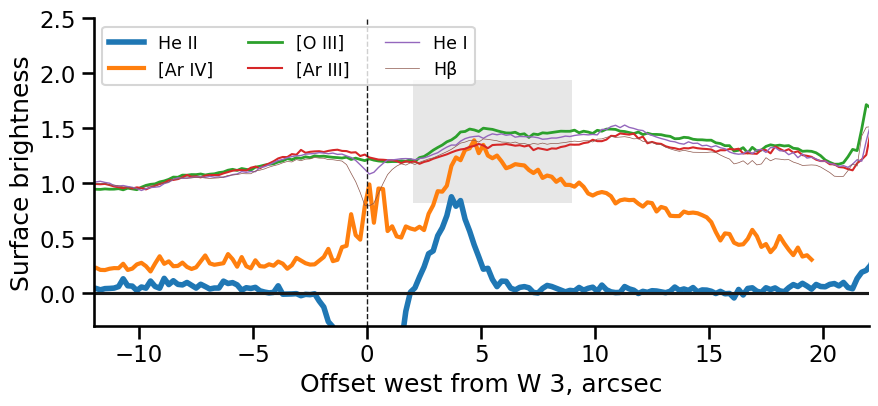

In [76]:
fig, ax = plt.subplots(figsize=(10, 4))
ix0 = 227.5
nx = len(heii_profile)
pos = (np.arange(nx) - ix0) * 0.2

def _norm(y, x, x1=-12, x2=-7):
    m = (x >= x1) & (x <= x2)
    return y / np.mean(y[m])


ax.plot(pos, _norm(heii_profile, pos, x1=2, x2=5) / 2, label="He II", lw=4)
ax.plot(pos, _norm(ariv_profile, pos) / 4, label="[Ar IV]", lw=3)
fac = 3 * 0.0014
ax.plot(pos, _norm(oiii_profile, pos), label="[O III]", lw=2.0)
fac = 3 * 0.145
ax.plot(pos, _norm(ariii_profile, pos), label="[Ar III]", lw=1.5)
fac = 3 * 0.100
ax.plot(pos, _norm(hei_profile, pos), label="He I", lw=1.0)
fac = 3 * 0.0105
ax.plot(pos, _norm(hb_profile, pos), label="Hβ", lw=0.5)


ax.axhline(0, color="k")

ax.axvline(0, color="k", lw=1, ls="dashed")
ax.axvspan(2.0, 9.0, 0.4, 0.8, color="k", alpha=0.1, linewidth=0, zorder=-100)
ax.legend(ncol=3, loc="upper left", fontsize="x-small")

ax.set(
    xlabel="Offset west from W 3, arcsec",
    ylabel="Surface brightness",
    xlim=[-12, 22],
    ylim=[-0.3, 2.5],
)
sns.despine()
fig.savefig(figdir / "ngc346-ZZ-bow-shock-brightness-cuts.pdf")

From the profile graph above, the peak He II brightness is about 400 MUSE brightness units

In [77]:
peak_heii_muse = np.max(heii_profile[(pos > 0) & (pos < 10)])
peak_heii_muse

399.3841857910156

In [78]:
peak_heii = muse_bright_unit * peak_heii_muse
peak_heii

<Quantity 1.39784465e-16 erg / (s arcsec2 cm2)>

In [79]:
mshell = (abs(pos) < 10) & (heii_profile > 100)
heii_profile[mshell]

masked_array(data=[108.4756329536438, 163.22602615356445,
                   175.01604347229005, 237.70564651489258,
                   270.88983154296875, 320.960863494873,
                   399.3841857910156, 360.2578063964844,
                   383.69867477416994, 306.2482486724854,
                   257.03363304138185, 199.76339988708497,
                   150.2915382385254, 102.65041160583496],
             mask=[False, False, False, False, False, False, False, False,
                   False, False, False, False, False, False],
       fill_value=1e+20)

In [80]:
pos[mshell]

array([2.5, 2.7, 2.9, 3.1, 3.3, 3.5, 3.7, 3.9, 4.1, 4.3, 4.5, 4.7, 4.9,
       5.3])

From the image, the chord length through the bow is about 60 pixels.  We can assume that the line-of-sight depth is similar:

In [81]:
depth_heii = 60 * 0.2 * 61700 * u.au
depth_heii.to(u.pc)

<Quantity 3.58956049 pc>

Surface brightness assuming optically thin emission with isotropic line emissivity, $e(\lambda)$, is given by
$$
I(\lambda) = \int \frac{e(\lambda)\, n_e\, n_i}{4 \pi} \, dz
$$
where $e(\lambda)$ is in the units given by pyneb: `u.erg * u.cm**3 / u.s` and $n_e$, $n_i$ are the electron and ion densities.

Assume neutral fractions of He and H are negligible and hydrogen number density is $n$.  If the He abundance is $y = n(\mathrm{He}) / n(\mathrm{H})$ and the He++ ion fraction is $x_{++}$, then we have:
$$
n(\mathrm{He^{++}}) = y\, x_{++}\, n \quad \text{and} \quad n_e = [1 + y\, (1 + x_{++})]\, n
$$
implying that
$$
n(\mathrm{He^{++}}) \, n_e = n_e^2 \, \frac{y\, x_{++}}{1 + y\, (1 + x_{++})}
$$

So, with homogeneous conditions, we have
$$
I(4686) =
\frac{e(4686)}{4\pi}\,
\frac{y\, x_{++}}{1 + (1 + x_{++}) y}
\, n_e^2 \, \delta z
$$
which can be solved for density to yield
$$
n_e = \left[
\frac{4\pi\, I(4686)}{\delta z\, e(4686)} \, \frac{1 + (1 + x_{++}) y}{x_{++}\,y}
\right]^{1/2}
$$

We can take the helium abundance from above and get ...

In [82]:
pn_e_units = u.erg * u.cm**3 / u.s
yHe = 0.0824
ne = np.sqrt(
    4
    * np.pi
    * u.sr
    * peak_heii
    / (depth_heii.cgs * e4686 * pn_e_units)
    * (1 + 2 * yHe)
    / yHe
).to(u.cm**-3)
ne

<Quantity [8.90415825, 9.37837181, 9.97207886] 1 / cm3>

**So electron density of 11 pcc!**

Note, however that this assumes that the helium is 100% doubly ionized in the 4686 emitting region. If it is only partially ionized, then this is a lower limit (density would scale approximately as $x_{++}^{-1/2}$).

The He II / Hb ratio is so low that the the ion fraction must be small. 

#### Find the He II flux and the He++ ionizing luminosity



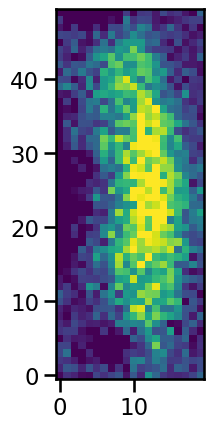

In [72]:
im4686[160:210, 235:255].plot(vmin=0, vmax=400)

In [73]:
muse_flux_unit = 1e-20 * 1.4 * u.erg / u.s / u.cm**2

Calculate the intrinsic flux of the He II line, taking into account the foreground extinction (calculated from the Balmer decrement in the previous notebook)

In [74]:
cutout = im4686[160:210, 235:255]
m = (cutout.data > 0.0) & ~cutout.mask
A_heii = 0.34
F_heii = muse_flux_unit * np.sum(cutout.data[m]) * 10 ** (0.4 * A_heii)
F_heii

<Quantity 2.80390915e-15 erg / (s cm2)>

In [28]:
D_lmc = 61700 * u.pc

In [29]:
L_heii = 4 * np.pi * D_lmc.cgs**2 * F_heii
L_heii

<Quantity 1.27715974e+33 erg / s>

In [30]:
L_heii.to(u.solLum)

<Quantity 0.3336363 solLum>

Effective recomb rate:

In [31]:
import astropy.constants as constants

In [32]:
hnu4686 = (constants.h * constants.c / (4686 * u.Angstrom)).cgs
hnu4686

<Quantity 4.23910768e-12 erg>

In [33]:
alpha_eff_4686 = e4686 * pn_e_units / hnu4686
alpha_eff_4686

<Quantity [2.83786139e-13, 2.55812655e-13, 2.26258816e-13] cm3 / s>

In [34]:
pn.atomicData.getAllAvailableFiles("He2")

['* 3he_ii_atom_cloudy.dat',
 '* 3he_ii_coll_cloudy.dat',
 '* he_ii_rec_SH95.hdf5',
 'he_ii_rec_P91.func',
 'he_ii_rec_SH95-caseA.fits',
 'he_ii_rec_SH95-caseA.hdf5',
 'he_ii_rec_SH95.fits',
 'he_ii_trc_SH95-caseA.dat',
 'he_ii_trc_SH95-caseB.dat']

It only works as follows:

In [35]:
pn.atomicData.setDataFile("he_ii_trc_SH95-caseB.dat")
alphaB_He_plus = pn.RecAtom("He", 2).getTotRecombination(tem=temperatures, den=100)
alphaB_He_plus *= u.cm**3 / u.s
alphaB_He_plus

<Quantity [1.29700000e-12, 1.20528923e-12, 1.10235464e-12] cm3 / s>

Solid angle:

Originally, I had assumed a +
/- 75 degree end cap. But after doing some estimates in the org file, I find that 54 +/- 16 deg is a better estimate

In [36]:
Omega_over_4pi = (1 - np.cos(54 * u.deg)) / 2
Omega_over_4pi

<Quantity 0.20610737>

$$
Q \frac{\Omega}{4\pi} = \int_{\mathcal{V}} n_e \, n_i \, \alpha_B\, d\mathcal{V}
$$
and
$$
L(4686) = \int_{\mathcal{V}} n_e \, n_i \, e(4686)\, d\mathcal{V}
$$
so that
$$
Q = \frac{\alpha_B \, L(4686)} {e(4686)\, (\Omega/4\pi)}
$$

In [37]:
Q2 = alphaB_He_plus * L_heii / (e4686 * pn_e_units) / Omega_over_4pi
Q2

<Quantity [6.68076260e+45, 6.88726020e+45, 7.12185401e+45] 1 / s>

This is way higher than what we got last time, which is due to including the effects of foreground extinction plus a smaller esitimate of the covering fraction. The uncertainty is +/- 50%, which is dominated by the uncertainty in the covering fraction.